## LIDA+ and LIDA++ Example Handbook

#### Table of contents:
* [Setup](#setup)
    * [Install packages](#installation)
    * [Imports](#imports)
    * [Initializing LIDA](#initializing-lida)
* [Summarizer Module](#summarizer-module)
    * [Default](#summarizer-default)
    * [Enrich](#summarizer-enrich)
    * [Describe](#summarizer-describe)
* [Goal Explorer Module](#goal-explorer-module)
    * [Generate goals](#goals-base)
    * [Generate goals with specific data types and number of variables](#generate-goals-that-guarantees-the-exploration-of-specific-data-types-andor-number-of-variables)
    * [Generate goals aligned With a persona](#generate-goals-with-a-persona)
    * [Generate goals related to an insight](#generate-goals-related-to-an-insight)
* [Viz Generator Module](#viz-generator-module)
    * [Generate a visualization rom a goal](#generate-a-visualization-from-a-goal)
    * [Generate a visualization from a custom prompt](#generate-a-visualization-from-a-custom-prompt)
    * [VizOps](#vizops)
        * [Edit a visualization](#edit-a-visualization)
        * [Explain a visualization](#explain-a-visualization)
        * [Evaluate a visualization](#evaluating-a-visualization)
        * [Repair a visualization](#repair-a-visualization)
* [Prompter Module](#prompter-module)
* [Insight Generator Module](#insight-explorer-module)
    * [Generate insights](#generate-insights)
    * [Generate insights with descriptions and a persona](#generate-insights-with-description)
    * [Generate more goals with an insight](#generating-more-goals-with-insight)
* [Research Assistant Module](#research-assistant-module)

## Setup <a class="anchor" id="setup"></a>

### Preparing environment variables 


### Install packages <a class="anchor" id="installation"></a>
Make sure that you did not install lida, as we want to locally import the lida library so that we can use the changes.

In [ ]:
%pip uninstall -y lida 
%pip install python-dotenv
%pip install llmx
%pip install langchain-openai
%pip install langchain-community
%pip install langchain
%pip install pandas
%pip install matplotlib
%pip install plotly
%pip install seaborn
%pip install chromadb
%pip install faiss-cpu
%pip install python-dotenv
%pip install beautifulsoup4
%pip install lxml

### Imports <a class="anchor" id="imports"></a>

In [14]:
import sys
import os
import pprint
import pickle #import this if you want to save your generated outputs for future use

In [15]:
sys.path.append(os.path.abspath('../..'))

from lida.components.manager import Manager
from llmx import TextGenerationConfig, llm

In [58]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Initializing LIDA <a class="anchor" id="initializing-lida"></a>

In [17]:
from dotenv import load_dotenv

load_dotenv()

True

In [64]:
lida = Manager(text_gen = llm("openai", api_key=os.getenv("OPENAI_APIKEY")))
textgen_config = TextGenerationConfig(n=1, temperature=0.5, model="gpt-4o-mini", use_cache=True)

## Summarizer Module <a class="anchor" id="summarizer-module"></a>

This modules creates a dense summary of the dataset. This will be used as grounding context for the other modules.

#### Fields
- `data*`: filepath to csv file 
- `description`: description of each column of the dataset (manually inputted)
- `file_name`: file name of the dataset
- `n_samples`: number of samples you want for each column
- `textgen_config`: llm config
    - View other settings [here](https://github.com/victordibia/llmx/blob/main/notebooks/tutorial.ipynb")
- `summary_method`: mode of summarizing
    - `default`: summarizes each column only without natural language descriptions
    - `enrich`: uses the llm to generate descriptions for every column and for the dataset
    - `describe`: takes in user input to add descriptions to the summary

### Default: Summarize the columns <a class="anchor" id="summarizer-default"></a>

In [74]:
summary = lida.summarize("../cars.csv", summary_method="default", textgen_config=textgen_config)  
pprint.pprint(summary)

{'dataset_description': '',
 'field_names': ['Name',
                 'Type',
                 'AWD',
                 'RWD',
                 'Retail_Price',
                 'Dealer_Cost',
                 'Engine_Size__l_',
                 'Cyl',
                 'Horsepower_HP_',
                 'City_Miles_Per_Gallon',
                 'Highway_Miles_Per_Gallon',
                 'Weight',
                 'Wheel_Base',
                 'Len',
                 'Width'],
 'fields': [{'column': 'Name',
             'properties': {'description': '',
                            'dtype': 'string',
                            'num_unique_values': 385,
                            'samples': ['Nissan Altima S 4dr',
                                        'Mercury Marauder 4dr',
                                        'Toyota Prius 4dr (gas/electric)'],
                            'semantic_type': ''}},
            {'column': 'Type',
             'properties': {'description': '',
       

### Enrich: Automatically generate descriptions for each column <a class="anchor" id="summarizer-enrich"></a>

In [24]:
enriched_summary = lida.summarize("../cars.csv", summary_method="enrich", textgen_config=textgen_config)  
pprint.pprint(enriched_summary)

{'dataset_description': 'This dataset contains information about various car '
                        'models, including their specifications, pricing, and '
                        'performance metrics.',
 'field_names': ['Name',
                 'Type',
                 'AWD',
                 'RWD',
                 'Retail_Price',
                 'Dealer_Cost',
                 'Engine_Size__l_',
                 'Cyl',
                 'Horsepower_HP_',
                 'City_Miles_Per_Gallon',
                 'Highway_Miles_Per_Gallon',
                 'Weight',
                 'Wheel_Base',
                 'Len',
                 'Width'],
 'fields': [{'column': 'Name',
             'properties': {'description': 'The name of the car model, '
                                           'including make, model, and type.',
                            'dtype': 'string',
                            'num_unique_values': 385,
                            'samples': ['Nissan Altima 

### Describe: Manually add descriptions for each column <a class="anchor" id="summarizer-describe"></a>

In [25]:
description = {
  "dataset_description": "This dataset contains detailed information about various cars, including specifications, performance metrics, and pricing. It is ideal for analyzing trends and patterns in the automotive industry.",
  "columns": {
    "Name": "Car model name, including brand.",
    "Type": "Classification of the car (e.g., sedan, SUV, truck).",
    "AWD": "Indicates if the car has All-Wheel Drive (true/false).",
    "RWD": "Indicates if the car has Rear-Wheel Drive (true/false).",
    "Retail_Price": "The car's retail price in dollars.",
    "Dealer_Cost": "Cost paid by dealers to acquire the car.",
    "Engine_Size__l_": "Engine size in liters.",
    "Cyl": "Number of engine cylinders.",
    "Horsepower_HP_": "Engine power measured in horsepower.",
    "City_Miles_Per_Gallon": "Fuel efficiency in city conditions (MPG).",
    "Highway_Miles_Per_Gallon": "Fuel efficiency in highway conditions (MPG).",
    "Weight": "Car weight in pounds or kilograms.",
    "Wheel_Base": "Distance between front and rear axles (in inches).",
    "Len": "Car length in inches or millimeters.",
    "Width": "Car width in inches or millimeters."
  }
}

In [26]:
described_summary = lida.summarize("../cars.csv", description=description, summary_method="describe", textgen_config=textgen_config)  
pprint.pprint(described_summary)

{'dataset_description': 'This dataset contains detailed information about '
                        'various cars, including specifications, performance '
                        'metrics, and pricing. It is ideal for analyzing '
                        'trends and patterns in the automotive industry.',
 'field_names': ['Name',
                 'Type',
                 'AWD',
                 'RWD',
                 'Retail_Price',
                 'Dealer_Cost',
                 'Engine_Size__l_',
                 'Cyl',
                 'Horsepower_HP_',
                 'City_Miles_Per_Gallon',
                 'Highway_Miles_Per_Gallon',
                 'Weight',
                 'Wheel_Base',
                 'Len',
                 'Width'],
 'fields': [{'column': 'Name',
             'properties': {'description': 'Car model name, including brand.',
                            'dtype': 'string',
                            'num_unique_values': 385,
                            's

## Goal Explorer Module <a class="anchor" id="goal-explorer-module"></a>

This module generates recommended questions for you to explore about your dataset.

#### Fields
- `summary*`: Summary from the summarizer
- `n`: Number of goals you want to generate
- `explore`: List of data types you want the goals to explore. 
    - `category`: Variables which are string or categories
    - `number`: Variables which are numerical (int, float)
    - `date`: Variables which are datetime
    - `three`: Mix of three or more variables
    - `two`: Mix of two variables
- `persona`: Description of your goal in exploring the dataset
- `insights`: List of insights you want to generate goals for
- `textgen_config`: llm config

### Generate goals (without specifications) <a class="anchor" id="goals-base"></a>
For this use case, we want goals that will let us openly explore our dataset without anything in mind. We do not specify data types we want to explore or any persona.

In [27]:
goals_bare_min = lida.goals(summary, n=3, textgen_config=textgen_config, explore=[])

for goal in goals_bare_min:
    display(goal)


### Goal 0
---
**Question:** How do the Retail Price and Dealer Cost compare across different car types?

**Visualization:** `bar chart of Type vs. average Retail_Price and average Dealer_Cost`

**Rationale:** This visualization will show the average Retail Price and Dealer Cost grouped by car Type. It helps us understand pricing strategies and market positioning for different types of vehicles, revealing potential pricing disparities and insights into consumer preferences.



### Goal 1
---
**Question:** What is the relationship between Engine Size and Horsepower across various car types?

**Visualization:** `scatter plot of Engine_Size__l_ vs. Horsepower_HP_ colored by Type`

**Rationale:** This scatter plot will highlight the correlation between Engine Size and Horsepower, with points colored by Type to identify patterns. It allows us to discern how different types of cars relate to performance metrics, aiding in understanding engineering choices and market trends.



### Goal 2
---
**Question:** What are the average City and Highway Miles Per Gallon by car type?

**Visualization:** `bar chart of Type vs. average City_Miles_Per_Gallon and average Highway_Miles_Per_Gallon`

**Rationale:** This visualization will compare the average fuel efficiency (City and Highway MPG) grouped by Type. It provides insights into the efficiency of different car types, which is crucial for understanding consumer preferences and environmental impacts.


### Generate goals that guarantees the exploration of specific data types and/or number of variables <a class="anchor" id="goals-var"></a>
For this use case, we want to specify that we want certain data types to be explored in our goal exploration. This will guarantee that there will be goals that exist that contain the data types we specify. Note that this does not mean that ALL goals will be constricted to the data types you specify. It only means that you want certain data types to be explored, but other goals will be generated as well.

We can populate the `explore` dataset with the data types we want to explore. We can also put `three` if we want to generate goals that will suggest visualizations for `three` different variables.

Note below that we see goals that include `date` columns and that there are goals that mix `three` variables.

In [28]:
goals_explore = lida.goals(summary, n=5, explore=['date', 'three'], textgen_config=textgen_config)

for goal in goals_explore:
    display(goal)


### Goal 0
---
**Question:** How does the Retail Price of cars vary by Type and Engine Size?

**Visualization:** `bar chart of average Retail_Price grouped by Type and Engine_Size__l_`

**Rationale:** This visualization helps to understand the relationship between car types and their pricing based on engine size. By grouping the data by Type and Engine_Size__l_, we can identify trends in pricing across different categories of cars, which can inform pricing strategies and consumer preferences.



### Goal 1
---
**Question:** How does the average Retail Price vary by Type of car?

**Visualization:** `bar chart of average Retail_Price grouped by Type`

**Rationale:** This visualization will help us understand the pricing structure of different car types. By grouping the data by the 'Type' column and calculating the average 'Retail_Price', we can identify which types are generally more expensive or affordable, providing insights into market trends and consumer preferences.



### Goal 2
---
**Question:** What is the relationship between Engine Size and Horsepower?

**Visualization:** `scatter plot of Engine_Size__l_ vs Horsepower_HP_`

**Rationale:** A scatter plot will effectively illustrate the correlation between 'Engine_Size__l_' and 'Horsepower_HP_'. This analysis can reveal whether larger engines typically produce more horsepower, which is critical for understanding performance metrics in the automotive industry.



### Goal 3
---
**Question:** What is the distribution of City Miles Per Gallon across different car Types?

**Visualization:** `box plot of City_Miles_Per_Gallon grouped by Type`

**Rationale:** Using a box plot allows us to visualize the distribution and variability of 'City_Miles_Per_Gallon' for each car type. This will provide insights into fuel efficiency across different categories, highlighting which types of cars are more economical for city driving.



### Goal 4
---
**Question:** How does the weight of cars vary with the number of Cylinders?

**Visualization:** `line chart of average Weight grouped by Cyl`

**Rationale:** This line chart will show the trend of average 'Weight' as the number of 'Cyl' increases. Analyzing this relationship can help us understand how engine design (in terms of cylinder count) impacts the overall weight of vehicles, which is essential for performance and fuel efficiency considerations.


### Generate goals with a persona <a class="anchor" id="goals-persona"></a>
For this use case, we want to specify our goal for our EDA so that LIDA can generate goals that will allow us to achieve our goal. 
Note below that we can see that the goals are tailored for our specific goal, more so than if we do not specify the persona.

In [35]:
persona = "A data analyst from a car dealership who wants to see how we can increase our revenue from this dataset and differentiate our brand from others"
goals_persona = lida.goals(summary, n=3, persona=persona, textgen_config=textgen_config, explore=[])

for goal in goals_persona:
    display(goal)


### Goal 0
---
**Question:** How does the Retail Price vary across different car Types?

**Visualization:** `bar chart of Retail_Price grouped by Type`

**Rationale:** This visualization will show the average Retail Price for each car Type, allowing the dealership to identify which types are priced higher and may attract different customer segments. By understanding this distribution, the dealership can strategize on pricing and marketing to differentiate their brand.



### Goal 1
---
**Question:** What is the relationship between Engine Size and Horsepower across different Types of cars?

**Visualization:** `scatter plot of Horsepower_HP_ vs. Engine_Size__l_ colored by Type`

**Rationale:** This scatter plot will reveal potential correlations between Engine Size and Horsepower for various car Types. Understanding these relationships can help the dealership highlight performance features in their marketing and tailor their inventory to meet consumer preferences.



### Goal 2
---
**Question:** How do City and Highway Miles Per Gallon compare for different Types of cars?

**Visualization:** `grouped bar chart of City_Miles_Per_Gallon and Highway_Miles_Per_Gallon by Type`

**Rationale:** This grouped bar chart will allow the dealership to compare fuel efficiency metrics for different Types of cars. Fuel efficiency is a critical decision factor for many consumers, and this insight can help the dealership position their vehicles more effectively in the market.


### Generate goals related to an insight <a class="anchor" id="goals-insight"></a>
For this use case, we have an insight about our data that we want to explore further. Note that the goals generated are now related to the insight that we provided.

In [32]:
goals_insight = lida.goals(summary, n=3, insights=["It looks like customers with families and customers without families prefer different car types"], textgen_config=textgen_config, explore=[])

for goal in goals_insight:
    display(goal)

Insight(insight='It looks like customers with families and customers without families prefer different car types', evidence={}, index=0)



### Goal 0
---
**Question:** How does the average Retail_Price of SUVs compare to Sedans and Sports Cars when controlling for Engine_Size__l_?

**Visualization:** `bar chart of average Retail_Price by Type, grouped by Engine_Size__l_`

**Rationale:** This is crucial because the type of vehicle often determines its price. Analyzing the average Retail_Price across different car types while controlling for Engine_Size__l_ will help us understand pricing trends and how family-oriented vehicles (like SUVs) differ from others, validating the initial insight.



### Goal 1
---
**Question:** Is there a relationship between City_Miles_Per_Gallon and Highway_Miles_Per_Gallon for different car types, and how does it affect their Retail_Price?

**Visualization:** `scatter plot of City_Miles_Per_Gallon vs. Highway_Miles_Per_Gallon, colored by Type, with Retail_Price as size of points`

**Rationale:** This visualization will help us see if higher fuel efficiency in cars correlates with higher Retail_Price, which may influence family preferences towards certain car types. Understanding this relationship can provide insights into consumer behavior and preferences.



### Goal 2
---
**Question:** What is the distribution of Horsepower_HP_ among different car types, and how does it relate to their weight?

**Visualization:** `box plot of Horsepower_HP_ by Type, with Weight as a secondary axis`

**Rationale:** This is important as horsepower and weight can significantly influence the performance and appeal of a vehicle to families versus single customers. Analyzing this distribution will reveal if family-oriented vehicles are typically lower in horsepower and weight, supporting the insight about different preferences.


## Viz Generator Module

This module generates a visualization based on a given goal or custom prompt.

- `summary*`: Summary of the dataset
- `goal*`: Goal that you want to make a visualization for
- `library`: Python library you want to use
    - `seaborn` (default)
    - `altair`
    - `plotly`
    - `matplotlib`
    - `ggplot`
- `textgen_config`: llm config

### Generate a visualization from a goal

For this use case, we select a goal that was generated previously. The goal is:



In [37]:
display(goals_persona[2])


### Goal 2
---
**Question:** How do City and Highway Miles Per Gallon compare for different Types of cars?

**Visualization:** `grouped bar chart of City_Miles_Per_Gallon and Highway_Miles_Per_Gallon by Type`

**Rationale:** This grouped bar chart will allow the dealership to compare fuel efficiency metrics for different Types of cars. Fuel efficiency is a critical decision factor for many consumers, and this insight can help the dealership position their vehicles more effectively in the market.


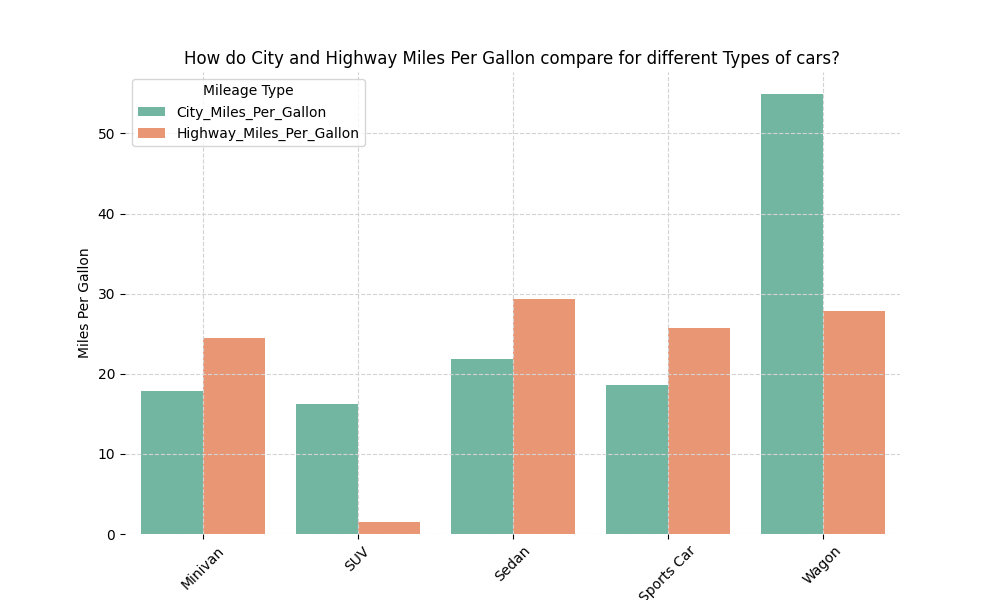

In [36]:
goal_charts = lida.visualize(summary=summary, goal=goals_persona[2], textgen_config=textgen_config)  
goal_charts[0]

### Generate a visualization from a custom prompt

For this use case, we provide our own prompt that we want to create a chart with. This works with different types of prompts as well:
1. High-level
2. Low-level

<string>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



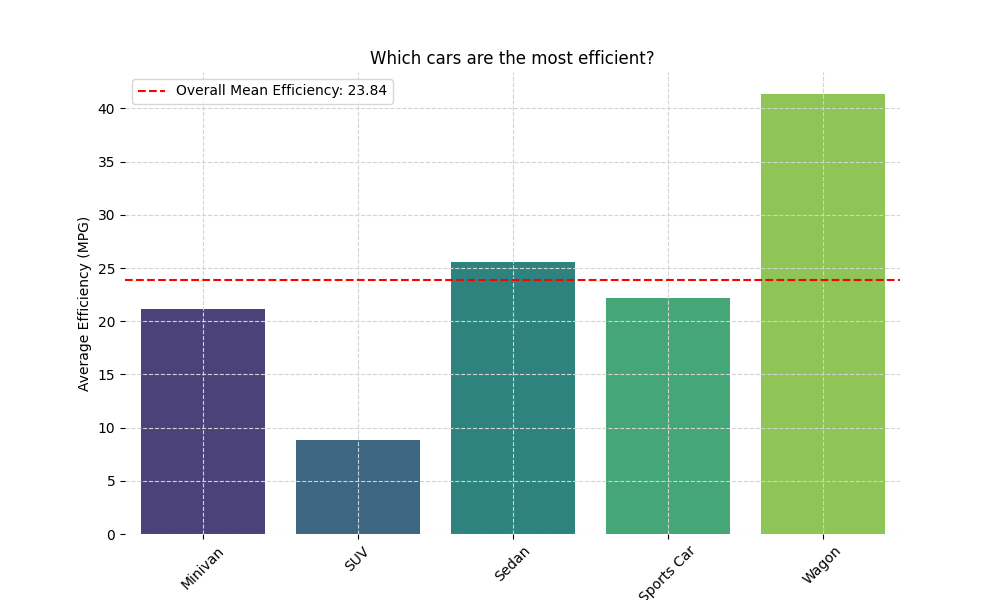

In [49]:
custom_chart_high_level = lida.visualize(summary=summary, goal="Which cars are the most efficient?", textgen_config=textgen_config)  
custom_chart_high_level[0]

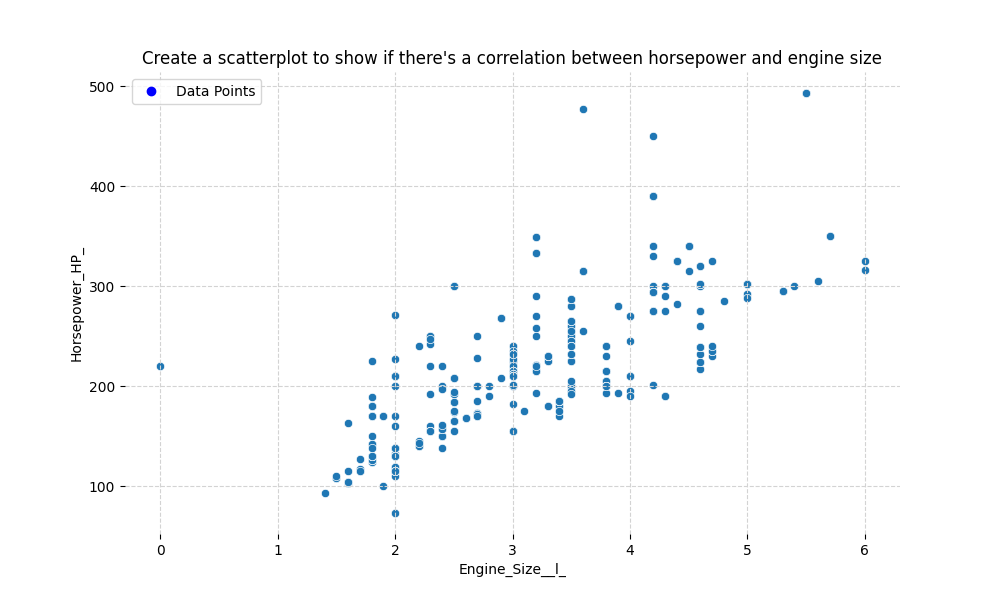

In [50]:
custom_chart_low_level = lida.visualize(summary=summary, goal="Create a scatterplot to show if there's a correlation between horepower and engine size", textgen_config=textgen_config)  
custom_chart_low_level[0]

## VizOps

We also have various operations we can do given our visualization such as:
1. Edit the visualization
2. Evaluate the visualization
3. Explain the visualization code
3. Repair the visualization

### Edit a visualization
Given a visualization, we have the option to edit it as well to match our specifications. There will be cases when the chart generated is not easily readable. This will be useful to manipulate it if there is something specific that you want to see.

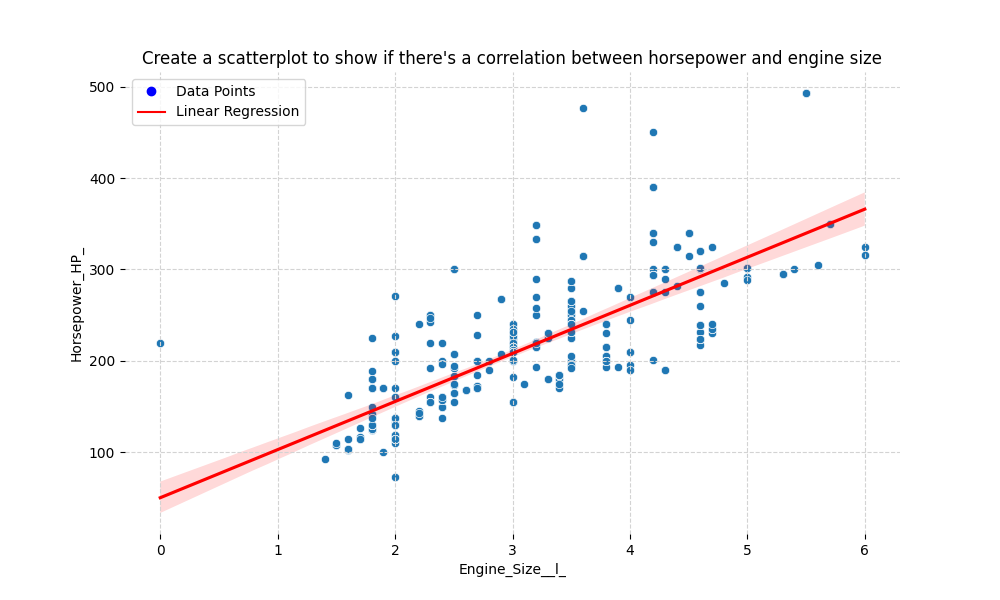

In [51]:
custom_chart_low_level_code = custom_chart_low_level[0].code
instructions = ["Show the linear regression"]
edited_charts = lida.edit(code=custom_chart_low_level_code,  summary=summary, instructions=instructions, textgen_config=textgen_config)
edited_charts[0]

### Evaluating a visualization

Given a visualization, we can use the LLM to rate it based on the original goal we had. This will be useful to see if there are points of improvement to visualize your data better. 
This is a weird visualization as an example

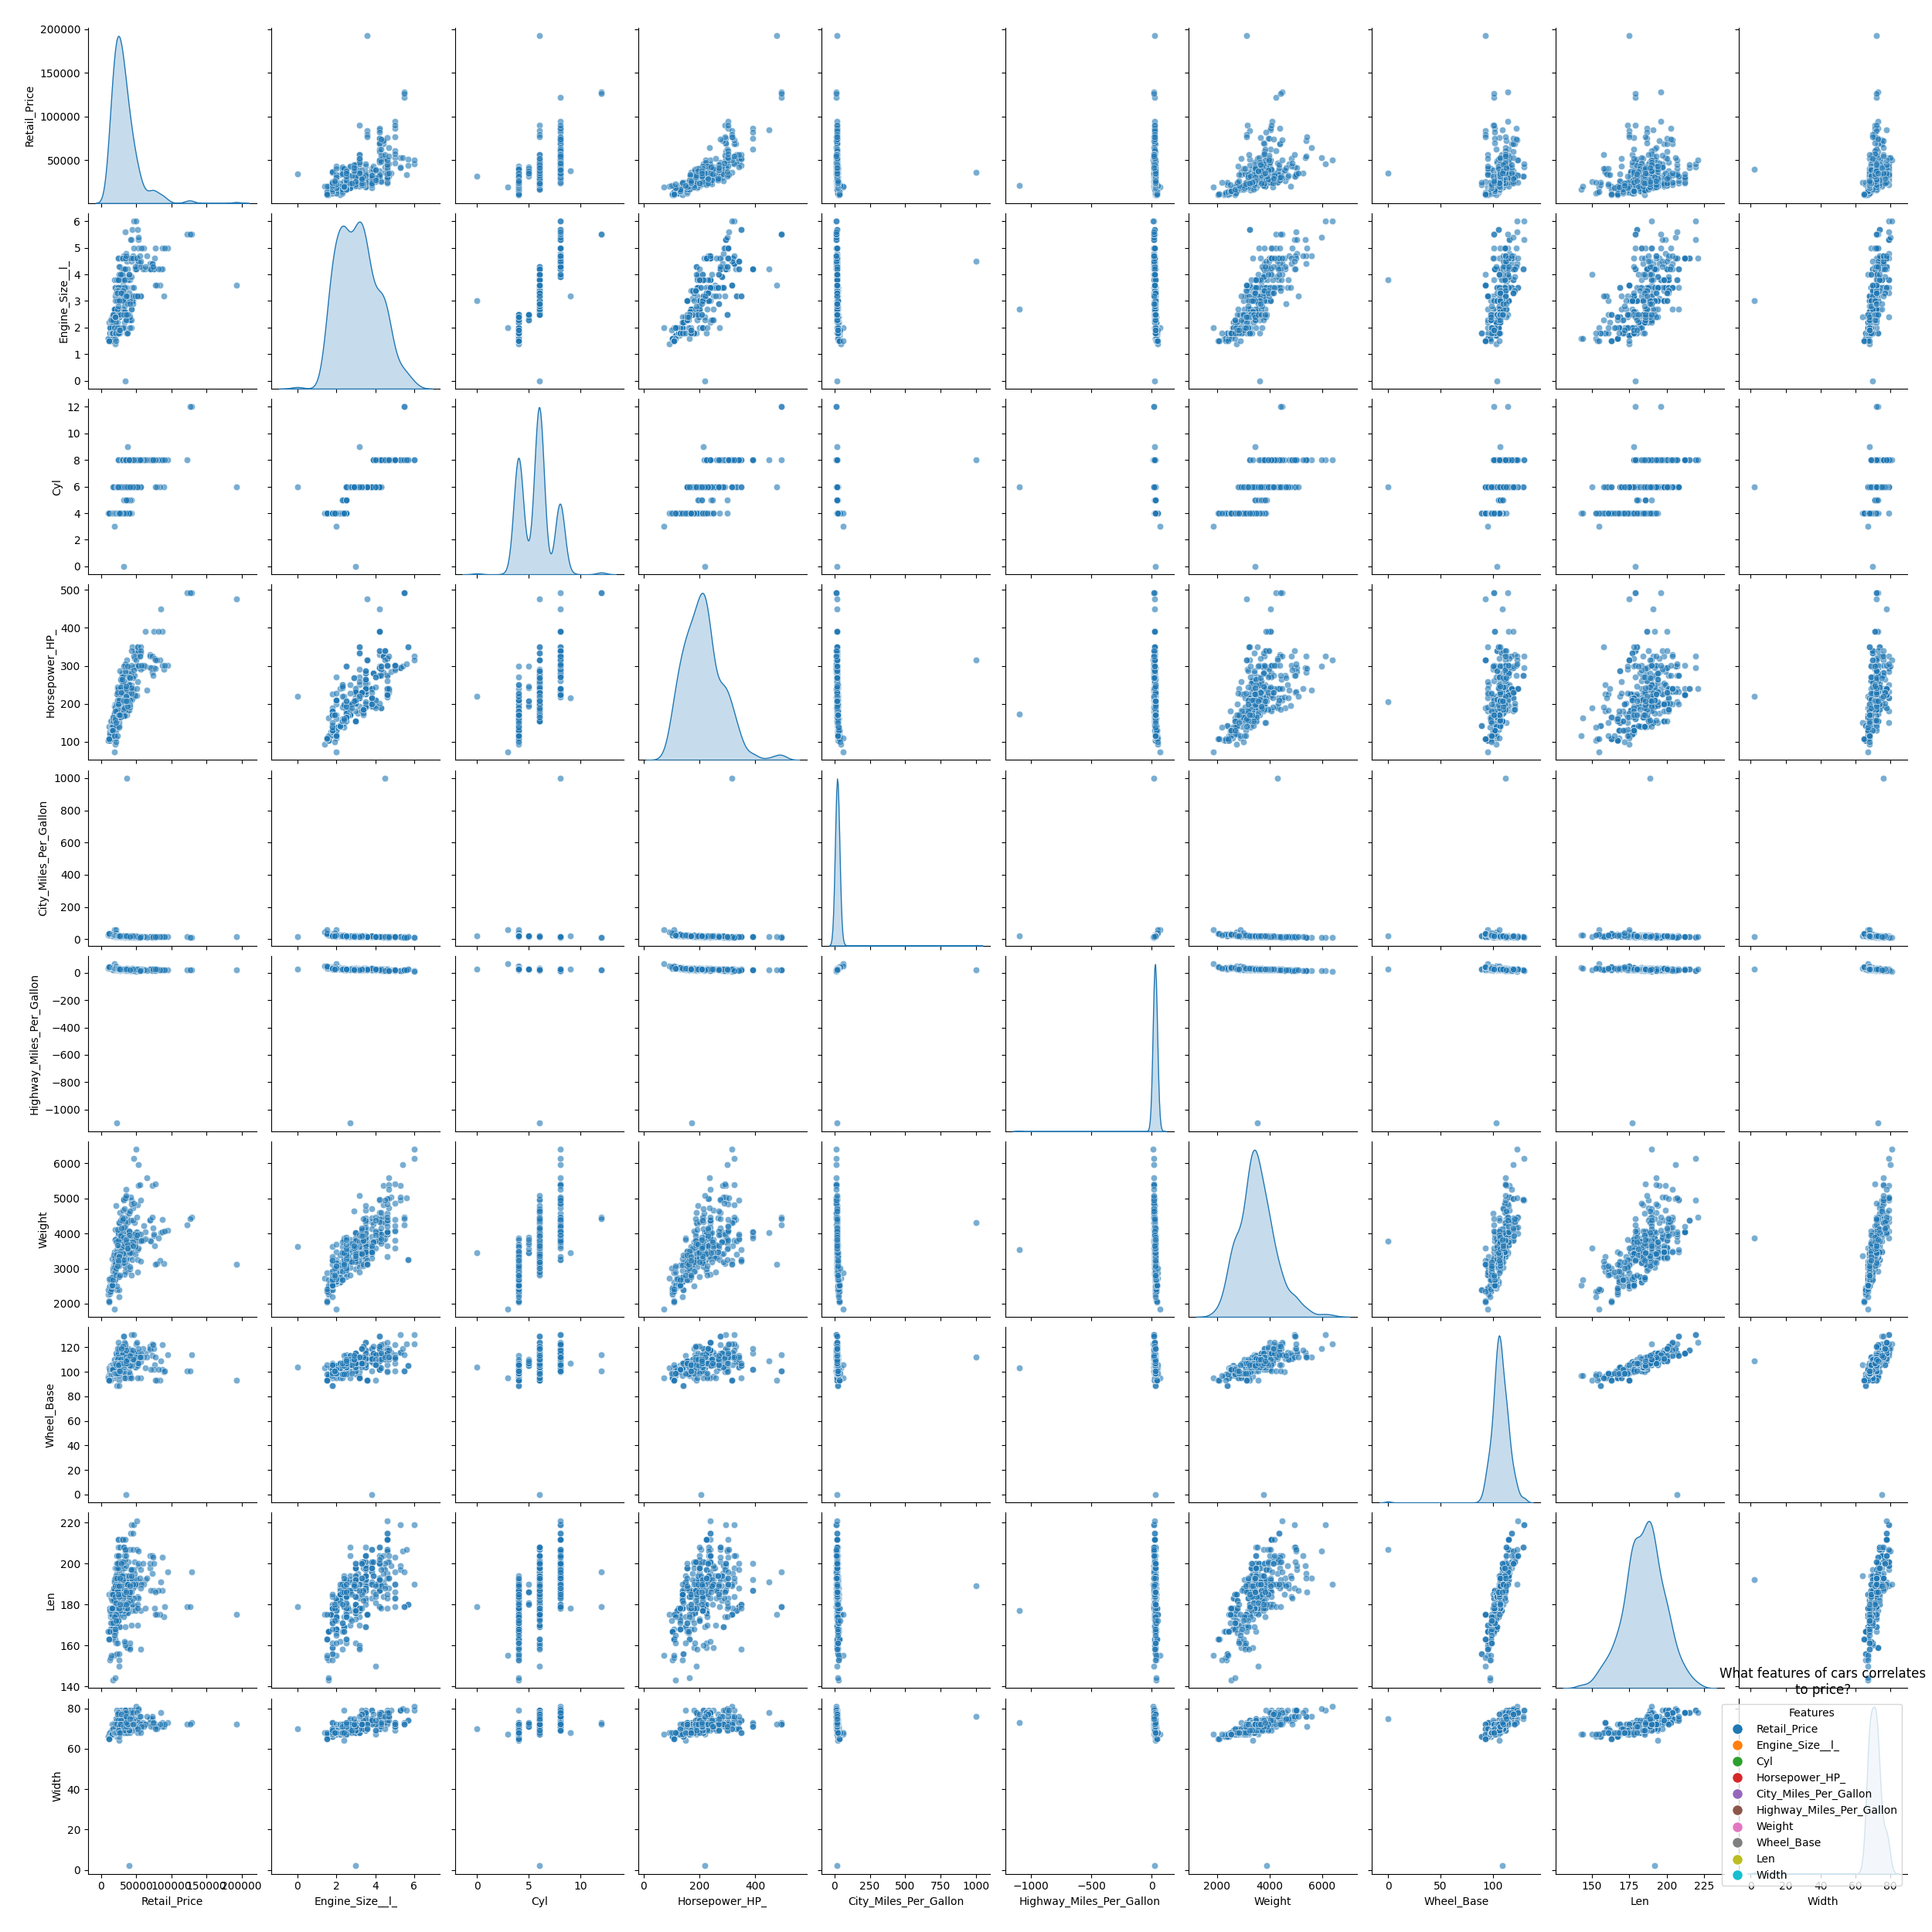

In [48]:
custom_chart = lida.visualize(summary=summary, goal="What features of cars correlates to price?", textgen_config=textgen_config)  
custom_chart[0]

In [68]:
feedback = lida.evaluate(code = custom_chart[0].code, goal="What features of cars correlates to price?", textgen_config=textgen_config)
display(feedback)

[[{'dimension': 'bugs',
   'score': 9,
   'rationale': 'There are no syntax errors or logical bugs in the code. It should compile and run successfully, provided the input DataFrame is valid.'},
  {'dimension': 'transformation',
   'score': 8,
   'rationale': 'The relevant numerical features are selected appropriately for correlation analysis. However, there is no filtering or grouping of the data which could enhance the insights.'},
  {'dimension': 'compliance',
   'score': 8,
   'rationale': "The code meets the goal of analyzing correlations with 'Retail_Price' through a pairplot, effectively visualizing relationships among features."},
  {'dimension': 'type',
   'score': 7,
   'rationale': 'A pairplot is an appropriate choice for visualizing multiple relationships, but it can become cluttered with too many features. A heatmap of correlations might provide clearer insights.'},
  {'dimension': 'encoding',
   'score': 8,
   'rationale': "Data is encoded appropriately for the pairplot, w

### Explain a visualization

There's also a lot of things happening in the visualization. How come the chart looks the way it does? Let's try to understand the code behind it.

In [67]:
explanation = lida.explain(code = custom_chart[0].code, textgen_config=textgen_config)
display(explanation)

[[{'section': 'accessibility',
   'code': "pairplot = sns.pairplot(data[numerical_features], diag_kind='kde', plot_kws={'alpha': 0.6})",
   'explanation': "The chart is a pairplot created using the Seaborn library, which visualizes the relationships between 'Retail_Price' and several other numerical features of cars. The pairplot displays scatter plots for each pair of features and kernel density estimates (KDE) along the diagonal, allowing for a comprehensive view of correlations. The points are semi-transparent (alpha=0.6) to enhance visibility. The goal of the chart is to analyze how different features relate to the retail price of cars, providing insights into which features may influence pricing."},
  {'section': 'transformation',
   'code': "numerical_features = ['Retail_Price', 'Engine_Size__l_', 'Cyl', 'Horsepower_HP_', 'City_Miles_Per_Gallon', 'Highway_Miles_Per_Gallon', 'Weight', 'Wheel_Base', 'Len', 'Width']",
   'explanation': "This section of the code selects a subset of n

### Repair a visualization

Finally, let's try to repair it. We use the feedback from the evaluation we did previously.

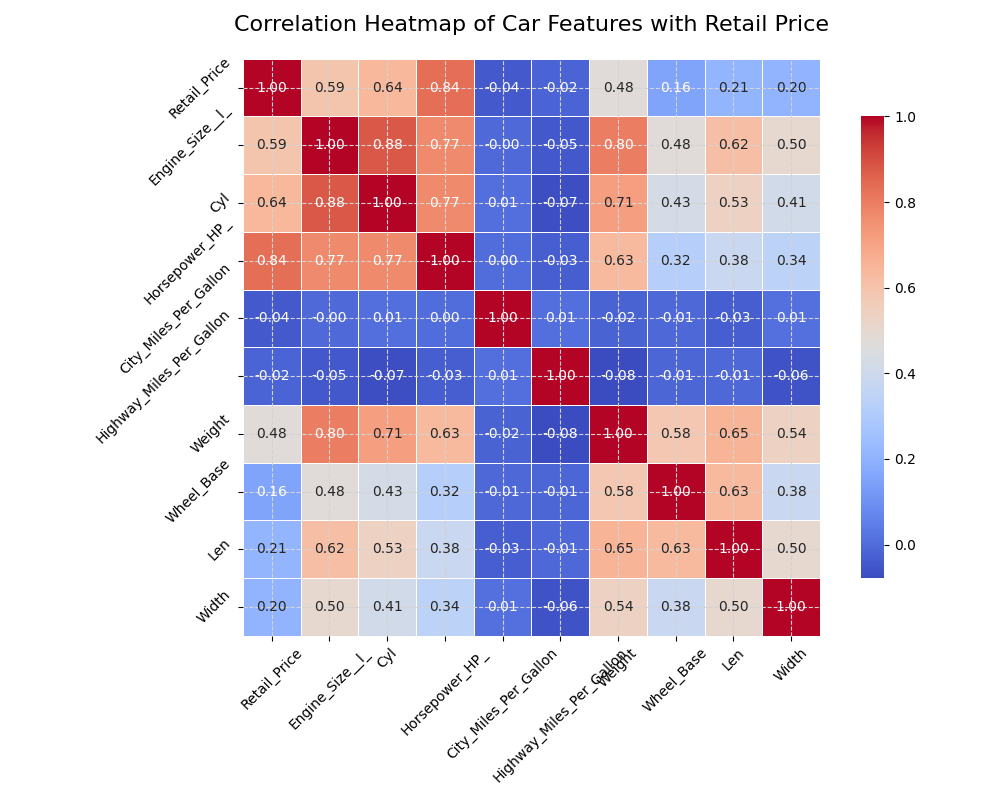

In [76]:
repaired_chart = lida.repair(summary=summary, code=custom_chart[0].code, goal="What features of cars correlates to price?", feedback=feedback, textgen_config=textgen_config)
repaired_chart[0]

## Prompter Module

Given a visualization or goal that you want to explore, you can use the prompter module to ask you questions about the visualization to guide your analysis

#### Fields
- `goal*`: Goal or visualization that you want to explore
- `n`: Number of prompts that you want to answer about your visualization
- `textgen_config`: llm config

In [78]:
goals_prompts = lida.prompt(goal="What features of cars correlates to price?", textgen_config=textgen_config, n=3)  

for prompt in goals_prompts:
    display(prompt)


### Prompt 0
---
**Question:** Which specific features show the strongest correlation with car prices?

**Rationale:** Understanding which features most significantly impact price can help in making informed decisions about pricing strategies or feature enhancements.




### Prompt 1
---
**Question:** Are there any outliers in the data that significantly affect the correlation?

**Rationale:** Identifying outliers can provide insights into exceptional cases that may skew the overall analysis, helping to refine the understanding of price determinants.




### Prompt 2
---
**Question:** How does the correlation vary across different car types or segments?

**Rationale:** This can reveal if certain features are more valuable in specific segments, guiding targeted marketing and product development efforts.



In [83]:
goals_answers=[
    "Engine size, cylinder and horsepower are the greatest",
    "Cylinder and engine size seems to have the greatest correlation among all of the other features",
    "I want to explore this more",
]

## Insight Explorer Module
This module generates recommended insights for you to explore given your answers to the prompter.

#### Fields
- `goal*`: Goal with the visualization description that you explored with the prompter
- `answers*`: Answers you gave to the prompter
- `prompts*`: Prompts that the prompter gave you
- `api_key`: Serper API key to allow it to generate search results to supplement the insights generated
- `description`: Dataset description to add more domain specific information when generating insights
- `persona`: Persona of the analyst and their goal
- `textgen_config`: llm config
- `n`: Nummber of insights to be generated

Before running the following cells, please add a `config` folder containing a `config.yaml` file in `lida/components/insight` containing the following information:

```python
openai_api_key: "sk-xxxxx"
serper_api_key: "xxxxx"

```

### Generate Insights

In [ ]:
goals_insights = lida.insights(goal="What features of cars correlates to price?", answers=goals_answers, prompts=goals_prompts, n=3, api_key=os.getenv("SERPER_APIKEY"))

for insight in goals_insights:
    display(insight)

[Document(metadata={'url': 'https://medium.com/@avi22nayak/analyzing-the-impact-of-car-features-on-price-and-profitability-08f01dc8b4f1'}, page_content='The automotive industry has been rapidly evolving over the past few decades, with a growing focus on fuel efficiency, environmental sustainability, and technological innovation. With increasing competition among manufacturers and a changing consumer landscape, it has become more important than ever to understand the factors that drive consumer demand for cars.In recent years, there has been a growing trend towards electric and hybrid vehicles and increased interest in alternative fuel sources such as hydrogen and natural gas. At the same time, traditional gasoline-powered cars remain dominant in the market, with varying fuel types and grades available to consumers.'), Document(metadata={'url': 'https://medium.com/@avi22nayak/analyzing-the-impact-of-car-features-on-price-and-profitability-08f01dc8b4f1'}, page_content='In this Project, t

c:\Users\User\Desktop\lida\lida\components\insight\retrieval.py:52: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  curr_references = retriever.get_relevant_documents(query)


### Generate Insights (with description)

You can opt to add the dataset description while generating the insights to provide more context to the LLM and add your persona.

In [94]:
goals_insights_with_desc = lida.insights(goal="What features of cars correlates to price?", answers=goals_answers, prompts=goals_prompts, n=3, description=description, api_key=os.getenv("SERPER_APIKEY"))

for insight in goals_insights_with_desc:
    display(insight)

[Document(metadata={'url': 'https://medium.com/@avi22nayak/analyzing-the-impact-of-car-features-on-price-and-profitability-08f01dc8b4f1'}, page_content='The automotive industry has been rapidly evolving over the past few decades, with a growing focus on fuel efficiency, environmental sustainability, and technological innovation. With increasing competition among manufacturers and a changing consumer landscape, it has become more important than ever to understand the factors that drive consumer demand for cars.In recent years, there has been a growing trend towards electric and hybrid vehicles and increased interest in alternative fuel sources such as hydrogen and natural gas. At the same time, traditional gasoline-powered cars remain dominant in the market, with varying fuel types and grades available to consumers.'), Document(metadata={'url': 'https://medium.com/@avi22nayak/analyzing-the-impact-of-car-features-on-price-and-profitability-08f01dc8b4f1'}, page_content='In this Project, t


### Insight 0
---
**Insight:** The strong correlation between engine size and car prices suggests that larger engines are perceived as more valuable, likely due to their association with higher performance and power. This is supported by the fact that bigger engines often lead to higher insurance costs, which can reflect their desirability and perceived risk [2]. Additionally, the relationship between engine size and fuel efficiency indicates that consumers may be willing to pay more for vehicles that balance power with efficiency, as smaller engines can be more efficient in urban settings [2].

**Evidence:** {'1': ['https://www.cuvva.com/how-insurance-works/engine-size-and-insurance-price', "As a general rule, the bigger your car's engine is, the more expensive it is to insure."], '2': ['https://www.cuvva.com/how-insurance-works/engine-size-and-insurance-price', 'The size of your engine matters because it determines how powerful your car is.']}



### Insight 1
---
**Insight:** The observation that cylinder count and engine size correlate strongly with car prices may indicate that consumers prioritize these features when making purchasing decisions. This could be due to the perception that more cylinders equate to better performance and reliability, which are critical factors in the automotive market [1]. Furthermore, the presence of outliers in cylinder count suggests that certain high-performance models may skew the average price, indicating a niche market where buyers are willing to pay a premium for specific features [5].

**Evidence:** {'1': ['https://medium.com/@avi22nayak/analyzing-the-impact-of-car-features-on-price-and-profitability-08f01dc8b4f1', 'I was able to get insights like which features effects Car Price, relationship between Engine Cylinders and it’s fuel efficiency.'], '2': ['https://medium.com/@yusufsutcu/car-price-prediction-a0ee9cdde5f0', 'It became evident that the outliers were mainly associated with kilometres and price variables.']}



### Insight 2
---
**Insight:** The varying correlation of features across different car types suggests that market segmentation plays a crucial role in pricing strategies. For instance, SUVs may prioritize engine size and horsepower more than sedans, which could lead to different pricing models based on consumer expectations for performance versus efficiency [1]. This indicates that a one-size-fits-all approach to pricing may overlook the nuanced preferences of different consumer segments, potentially leading to missed opportunities in targeted marketing [4].

**Evidence:** {'1': ['https://medium.com/@avi22nayak/analyzing-the-impact-of-car-features-on-price-and-profitability-08f01dc8b4f1', 'I also got experience in Data Preprocessing like Data Cleaning, handling Outliers, Feature Engineering etc.'], '2': ['https://www.linkedin.com/pulse/mastering-outliers-data-driven-journey-used-car-prices-mahmuda-yasmin-mtewc', 'This piqued my curiosity - I’ll be following to see what trends you discover!']}


#### Generating More Goals with Insight

You can explore the insights further with the Goal Explorer as follows. Let's explore this insight:

In [104]:
display(goals_insights_with_desc[0])


### Insight 0
---
**Insight:** The strong correlation between engine size and car prices suggests that larger engines are perceived as more valuable, likely due to their association with higher performance and power. This is supported by the fact that bigger engines often lead to higher insurance costs, which can reflect their desirability and perceived risk [2]. Additionally, the relationship between engine size and fuel efficiency indicates that consumers may be willing to pay more for vehicles that balance power with efficiency, as smaller engines can be more efficient in urban settings [2].

**Evidence:** {'1': ['https://www.cuvva.com/how-insurance-works/engine-size-and-insurance-price', "As a general rule, the bigger your car's engine is, the more expensive it is to insure."], '2': ['https://www.cuvva.com/how-insurance-works/engine-size-and-insurance-price', 'The size of your engine matters because it determines how powerful your car is.']}


In [105]:
goals_insight2 = lida.goals(summary, n=3, insights=[goals_insights_with_desc[0]], textgen_config=textgen_config, explore=[])

for goal in goals_insight2:
    display(goal)

Insight(insight='The strong correlation between engine size and car prices suggests that larger engines are perceived as more valuable, likely due to their association with higher performance and power. This is supported by the fact that bigger engines often lead to higher insurance costs, which can reflect their desirability and perceived risk [2]. Additionally, the relationship between engine size and fuel efficiency indicates that consumers may be willing to pay more for vehicles that balance power with efficiency, as smaller engines can be more efficient in urban settings [2].', evidence={'1': ['https://www.cuvva.com/how-insurance-works/engine-size-and-insurance-price', "As a general rule, the bigger your car's engine is, the more expensive it is to insure."], '2': ['https://www.cuvva.com/how-insurance-works/engine-size-and-insurance-price', 'The size of your engine matters because it determines how powerful your car is.']}, index=0)



### Goal 0
---
**Question:** How does the average Retail Price of cars with different Engine Sizes compare, and what is the impact of Type on this relationship?

**Visualization:** `bar chart of average Retail_Price grouped by Engine_Size__l_ and Type`

**Rationale:** This is crucial because understanding how engine size impacts retail price across different car types can reveal consumer preferences and market dynamics. Using this visualization will show if larger engines are consistently associated with higher prices across all types, confirming the insight regarding perceived value.



### Goal 1
---
**Question:** Is there a relationship between Engine Size and City Miles Per Gallon, and how does it vary with the Type of car?

**Visualization:** `scatter plot of Engine_Size__l_ vs. City_Miles_Per_Gallon, colored by Type`

**Rationale:** This is important because it helps identify how engine size affects fuel efficiency in urban settings, which is a key factor in consumer decision-making. This visualization will reveal if smaller engines are indeed more efficient, supporting the insight about the balance between power and efficiency.



### Goal 2
---
**Question:** What is the average Horsepower of cars with different Engine Sizes, and how does this differ by Type?

**Visualization:** `box plot of Horsepower_HP_ grouped by Engine_Size__l_ and Type`

**Rationale:** This is crucial as it demonstrates the performance expectations associated with engine size across various types of vehicles. By exploring this visualization, we can confirm whether larger engines correlate with higher horsepower, thus validating the insight about their desirability and performance.


## Research Assistant Module
This module generates recommended insights for you to explore given your answers to the prompter. It uses the same fields as the insight explorer, but it doesn't directly attempt to generate insights for you. This module is meant to probe you further to explore your data in a meaningful way.


#### Fields
- `goal*`: Goal with the visualization description that you explored with the prompter
- `answers*`: Answers you gave to the prompter
- `prompts*`: Prompts that the prompter gave you
- `api_key`: Serper API key to allow it to generate search results to supplement the insights generated
- `description`: Dataset description to add more domain specific information when generating insights
- `persona`: Persona of the analyst and their goal
- `textgen_config`: llm config
- `n`: Nummber of insights to be generated

In [95]:
researches = lida.research(goal="What features of cars correlates to price?", answers=goals_answers, prompts=goals_prompts, n=3, description=description, api_key=os.getenv("SERPER_APIKEY"))

for research in researches:
    display(research)

[Document(metadata={'url': 'https://medium.com/@avi22nayak/analyzing-the-impact-of-car-features-on-price-and-profitability-08f01dc8b4f1'}, page_content='The automotive industry has been rapidly evolving over the past few decades, with a growing focus on fuel efficiency, environmental sustainability, and technological innovation. With increasing competition among manufacturers and a changing consumer landscape, it has become more important than ever to understand the factors that drive consumer demand for cars.In recent years, there has been a growing trend towards electric and hybrid vehicles and increased interest in alternative fuel sources such as hydrogen and natural gas. At the same time, traditional gasoline-powered cars remain dominant in the market, with varying fuel types and grades available to consumers.'), Document(metadata={'url': 'https://medium.com/@avi22nayak/analyzing-the-impact-of-car-features-on-price-and-profitability-08f01dc8b4f1'}, page_content='In this Project, t


### Research 0
---
**Reference:** {'1': ['https://medium.com/@avi22nayak/analyzing-the-impact-of-car-features-on-price-and-profitability-08f01dc8b4f1', 'I was able to get insights like which features effects Car Price, relationship between Engine Cylinders and it’s fuel efficiency etc.'], '2': ['https://www.cuvva.com/how-insurance-works/engine-size-and-insurance-price', 'The size of your engine matters because it determines how powerful your car is.']}

**Prompt:** How do engine size and the number of cylinders interact to influence car prices across different segments, such as sedans versus SUVs?



### Research 1
---
**Reference:** {'1': ['https://www.linkedin.com/pulse/mastering-outliers-data-driven-journey-used-car-prices-mahmuda-yasmin-mtewc', 'It became evident that the outliers were mainly associated with kilometres and price variables.'], '2': ['https://medium.com/@yusufsutcu/car-price-prediction-a0ee9cdde5f0', 'Now without outliers we can see more clearly that as age and mileage increase, we observe that the price decreases.']}

**Prompt:** What role do outliers play in the correlation between engine size, cylinder count, and car prices, and how can we effectively manage them in our analysis?



### Research 2
---
**Reference:** {'1': ['https://medium.com/@avi22nayak/analyzing-the-impact-of-car-features-on-price-and-profitability-08f01dc8b4f1', 'Through this project, I was able to understand the importance of Data Analytics in Car Feature Analysis as it provides valuable insights.'], '2': ['https://www.cuvva.com/how-insurance-works/engine-size-and-insurance-price', 'A bigger engine means your car will be more powerful, which would put it in a higher insurance group.']}

**Prompt:** How does the relationship between horsepower and engine size vary across different car types, and what implications does this have for pricing strategies?
